In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
df = pd.read_excel('iris.xlsx')


In [4]:
df.head()

,sepallength,sepalwidth,petallength,petalwidth,class
0,7.9,3.8,6.4,2.0,Iris-virginica
1,7.7,3.8,6.7,2.2,Iris-virginica
2,7.7,3.0,6.1,2.3,Iris-virginica
3,7.7,2.8,6.7,2.0,Iris-virginica
4,7.7,2.6,6.9,2.3,Iris-virginica


In [5]:
df['class'].value_counts()

class
Iris-virginica     50
Iris-versicolor    50
Iris-setosa        50
Name: count, dtype: int64

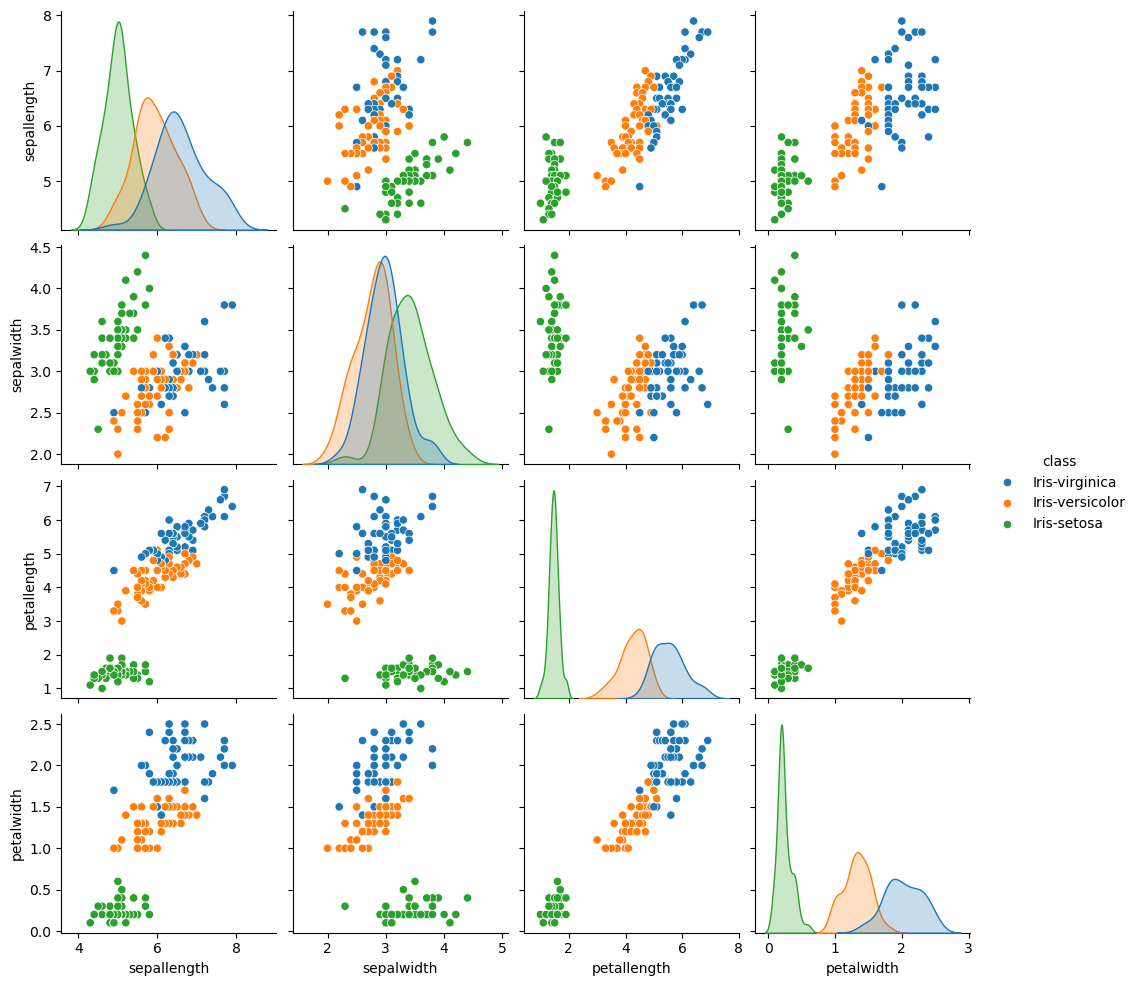

In [6]:
sns.pairplot(df,hue='class')

In [7]:
x= df.iloc[:,:-1]
y = df.iloc[:,-1]   

In [8]:
enc = LabelEncoder()
y_int = enc.fit_transform(y)

In [9]:
y_int

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2,
       2, 1, 1, 2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2,
       1, 1, 2, 1, 0, 2, 2, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0])

In [10]:
x_train,x_test,y_train,y_test  = train_test_split(x,y_int,test_size=0.2,random_state=42,stratify=y_int)

In [11]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [12]:
per =Perceptron(max_iter=100,random_state=42)
per.fit(x_train_scaled,y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [13]:
y_predict_per = per.predict(x_test_scaled)

In [14]:
accuracy_score(y_predict_per,y_test)

0.8666666666666667

In [15]:
print(classification_report(y_test,y_predict_per))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.88      0.70      0.78        10
           2       0.90      0.90      0.90        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.86        30
weighted avg       0.87      0.87      0.86        30



In [16]:
y_train_cat = to_categorical(y_train,num_classes=3)
y_test_cat = to_categorical(y_test,num_classes=3)

In [17]:
model = Sequential([
    Dense(16,input_dim = 4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])

C:\Users\patel\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer='adam',loss ='categorical_crossentropy',metrics=['accuracy'])

In [19]:
history = model.fit(x_train_scaled,y_train_cat,validation_split=0.2,epochs= 100, batch_size=8,verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3958 - loss: 1.1252 - val_accuracy: 0.5000 - val_loss: 0.9566
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4479 - loss: 1.0469 - val_accuracy: 0.5833 - val_loss: 0.9094
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4688 - loss: 0.9924 - val_accuracy: 0.5833 - val_loss: 0.8758
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5104 - loss: 0.9497 - val_accuracy: 0.6250 - val_loss: 0.8426
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6042 - loss: 0.9112 - val_accuracy: 0.6667 - val_loss: 0.8073
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6354 - loss: 0.8750 - val_accuracy: 0.7500 - val_loss: 0.7773
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6667 - loss: 0.8433 - val_accuracy: 0.7500 - val_loss: 0.7526
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6875 - loss: 0.8161 - val_accuracy: 0.7

In [20]:
loss, acc = model.evaluate(x_test_scaled, y_test_cat, verbose=1)
print(acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9000 - loss: 0.1945
0.8999999761581421


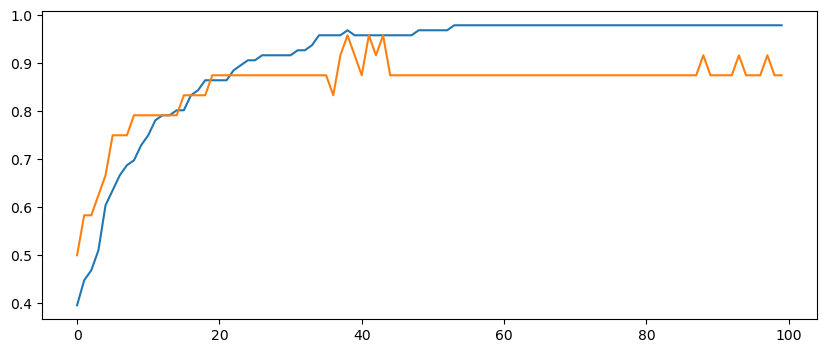

In [21]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'],label = 'train_acc')
plt.plot(history.history['val_accuracy'],label = 'val_acc')